<a href="https://colab.research.google.com/github/walter-04/TFM_Canine/blob/feature%2FVibe_codec/notebooks/unific_size_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libs

In [1]:
from nibabel.affines import rescale_affine, voxel_sizes
from nibabel.processing import resample_from_to
import matplotlib.pyplot as plt
import nibabel as nib
import glob

In [2]:
from google.colab import drive
drive.mount('/content/drive')
path_drive_data = "/content/drive/MyDrive/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Transformar formato

> Esta clase se encarga cambiar las dimensiones de los datos a partir de una imagen de referencia.



In [4]:
# Si no se utiliza drive, especificar ruta
path_base = "/content/drive/MyDrive/"

In [5]:
class Formate_nii:

  def __init__(self, init_nii, file_out):
    '''
    params:
      init_nii: ruta de la imagen a
      file_out: nombre de la carpeta de salida
    '''
    self.cort_z = 250
    self.img_base_nii = nib.load(init_nii)
    self.path_img_base = init_nii.split('/')[-1]
    self.path_out = f"{path_base}/{file_out}/"

  def resample_nii(self, img_nii):
    '''
    params:
      img_nii: imagen a procesar
    return:
      img_nii_resize: imagen procesada
    '''
    new_matrix_affine = rescale_affine(img_nii.affine,
                                shape=img_nii.shape,
                                zooms=voxel_sizes(self.img_base_nii.affine),
                                new_shape=self.img_base_nii.shape)

    img_nii_resize = resample_from_to(img_nii,
                                (self.img_base_nii.shape, new_matrix_affine),
                                order=1, mode='nearest')
    return img_nii_resize

  def run(self, path_data):
    '''
    params:
      path_data: ruta de la carpeta con las imagenes a procesar
    '''
    files_nii = glob.glob(path_data)
    for file in files_nii:
      if self.path_img_base not in file:
        img_nii = nib.load(file)
        name_file_nii = file.split('/')[-1]
        img_nii_resize = self.resample_nii(img_nii)
        print("Tratando:", file)
        print(" * Resample:",img_nii.shape," a ", img_nii_resize.shape)
        nib.save(img_nii_resize, f'{self.path_out}{name_file_nii}')

#Ejecución

> Se llama al proceso de transformación pasando el fichero base del que se obtienen las caracteristicas. Además, se pasa el directorio de salida del proceso. Por último, se llama al método run con el directorio con los datos a transformar.



In [ ]:
formate = Formate_nii("/content/drive/MyDrive/data_nii/sub-18_T1w.nii",
                      "data_nii_resize_max_18")
formate.run("/content/drive/MyDrive/data_nii/*")

#Validación

> Se cargan la imagenes para evaluar las transformaciones que se han aplicado en cada una de las imagenes. Se debe cargar cada imagen de forma individual



In [17]:
imagen_referencia = nib.load("/content/drive/MyDrive/data_nii/sub-18_T1w.nii")\
                        .get_fdata()
imagen_original = nib.load("/content/drive/MyDrive/data_nii/sub-34_T1w.nii")\
                     .get_fdata()
imagen_resize = nib.load("/content/drive/MyDrive/data_nii_resize_max_18/sub-34_T1w.nii")\
                     .get_fdata()

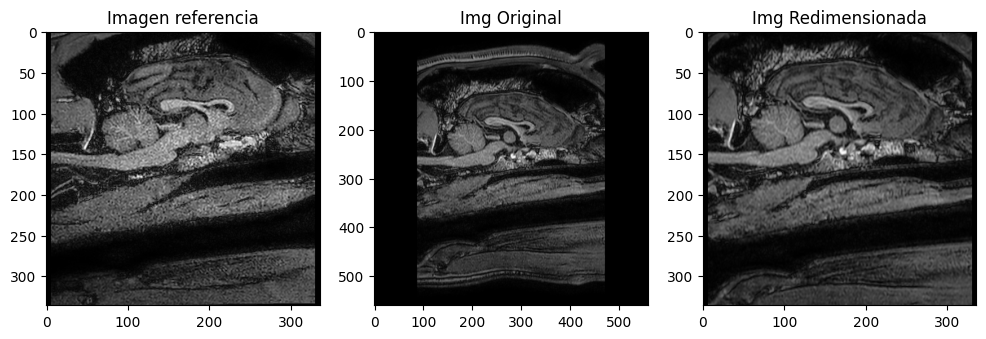

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes.ravel()
ax[0].set_title('Imagen referencia')
ax[0].imshow(imagen_referencia[int(imagen_referencia.shape[0]/2),: ,:], cmap='Greys_r')
ax[1].set_title('Img Original')
ax[1].imshow(imagen_original[int(imagen_original.shape[0]/2),:,:], cmap='Greys_r')
ax[2].set_title('Img Redimensionada')
ax[2].imshow(imagen_resize[int(imagen_resize.shape[0]/2),:,:], cmap='Greys_r')

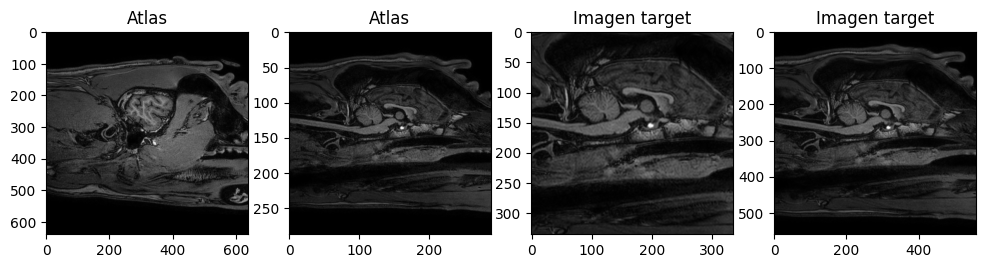

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
ax = axes.ravel()
ax[0].set_title('Atlas')
ax[0].imshow(image_or.get_fdata()[125,:,:], cmap='Greys_r')
ax[1].set_title('Atlas')
ax[1].imshow(image_pe.get_fdata()[125,:,:], cmap='Greys_r')
ax[2].set_title('Imagen target')
ax[2].imshow(image_pe_2.get_fdata()[125,:,:], cmap='Greys_r')
ax[3].set_title('data_nii_resize_max')
ax[3].imshow(img_grand.get_fdata()[200,:,:], cmap='Greys_r')